## Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## Loading The Dataset

In [2]:
df = pd.read_csv("powerconsumption.csv")

df.head()

,Datetime,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
0,1/1/2017 0:00,6.559,73.8,0.083,0.051,0.119,34055.69620,16128.87538,20240.96386
1,1/1/2017 0:10,6.414,74.5,0.083,0.070,0.085,29814.68354,19375.07599,20131.08434
2,1/1/2017 0:20,6.313,74.5,0.080,0.062,0.100,29128.10127,19006.68693,19668.43373
3,1/1/2017 0:30,6.121,75.0,0.083,0.091,0.096,28228.86076,18361.09422,18899.27711
4,1/1/2017 0:40,5.921,75.7,0.081,0.048,0.085,27335.69620,17872.34043,18442.40964


##  Feature Engineering

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52416 entries, 0 to 52415
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Datetime                52416 non-null  object 
 1   Temperature             52416 non-null  float64
 2   Humidity                52416 non-null  float64
 3   WindSpeed               52416 non-null  float64
 4   GeneralDiffuseFlows     52416 non-null  float64
 5   DiffuseFlows            52416 non-null  float64
 6   PowerConsumption_Zone1  52416 non-null  float64
 7   PowerConsumption_Zone2  52416 non-null  float64
 8   PowerConsumption_Zone3  52416 non-null  float64
dtypes: float64(8), object(1)
memory usage: 3.6+ MB


In [4]:
df.describe()

,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
count,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000,52416.000000
mean,18.810024,68.259518,1.959489,182.696614,75.028022,32344.970564,21042.509082,17835.406218
std,5.815476,15.551177,2.348862,264.400960,124.210949,7130.562564,5201.465892,6622.165099
min,3.247000,11.340000,0.050000,0.004000,0.011000,13895.696200,8560.081466,5935.174070
25%,14.410000,58.310000,0.078000,0.062000,0.122000,26310.668692,16980.766032,13129.326630
50%,18.780000,69.860000,0.086000,5.035500,4.456000,32265.920340,20823.168405,16415.117470
75%,22.890000,81.400000,4.915000,319.600000,101.000000,37309.018185,24713.717520,21624.100420
max,40.010000,94.800000,6.483000,1163.000000,936.000000,52204.395120,37408.860760,47598.326360


In [5]:
df.shape

(52416, 9)

<Axes: >

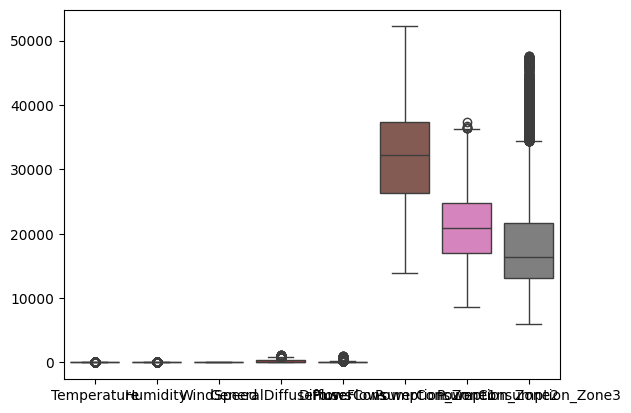

In [6]:
sns.boxplot(data=df)

In [ ]:
df.shape

(44349, 8)

## Data Cleaning

In [8]:
# Drop non-numeric column
df = df.drop(columns=["Datetime"])

# Check missing values
print(df.isnull().sum())

Temperature               0
Humidity                  0
WindSpeed                 0
GeneralDiffuseFlows       0
DiffuseFlows              0
PowerConsumption_Zone1    0
PowerConsumption_Zone2    0
PowerConsumption_Zone3    0
dtype: int64


In [9]:
#removing outliers
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1
df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]


## Data Scaling

In [10]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Convert back to DataFrame (optional but useful)
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

scaled_df.head()

,Temperature,Humidity,WindSpeed,GeneralDiffuseFlows,DiffuseFlows,PowerConsumption_Zone1,PowerConsumption_Zone2,PowerConsumption_Zone3
0,-2.095028,0.244961,-0.762012,-0.585084,-0.651725,0.333246,-0.876257,0.536411
1,-2.121614,0.293425,-0.762012,-0.584994,-0.652254,-0.260907,-0.247142,0.517757
2,-2.140132,0.293425,-0.763305,-0.585032,-0.652021,-0.357096,-0.318536,0.439215
3,-2.175335,0.328042,-0.762012,-0.584894,-0.652083,-0.483076,-0.443652,0.308639
4,-2.212005,0.376506,-0.762874,-0.585099,-0.652254,-0.608206,-0.538373,0.231078


## K-means Clusturing for K=3

In [11]:
kmeans_3 = KMeans(n_clusters=3, random_state=42)
clusters_3 = kmeans_3.fit_predict(scaled_df)

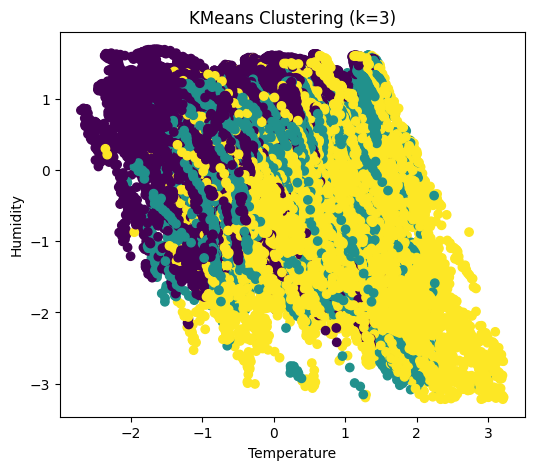

In [12]:
plt.figure(figsize=(6,5))
plt.scatter(scaled_df.iloc[:, 0], scaled_df.iloc[:, 1], c=clusters_3)
plt.title("KMeans Clustering (k=3)")
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.show()

## K-means clusturing for K=4

In [13]:
kmeans_4 = KMeans(n_clusters=4, random_state=42)
clusters_4 = kmeans_4.fit_predict(scaled_df)

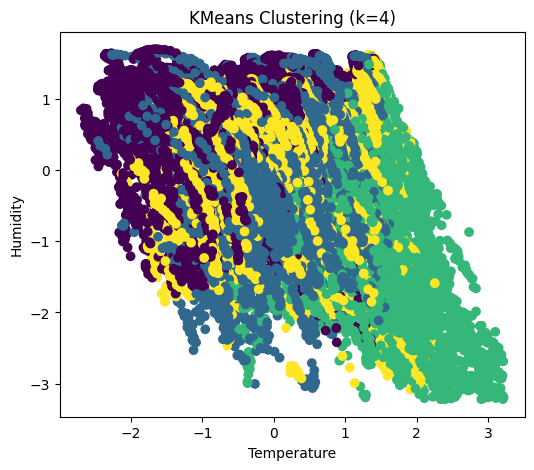

In [14]:
plt.figure(figsize=(6,5))
plt.scatter(scaled_df.iloc[:, 0], scaled_df.iloc[:, 1], c=clusters_4)
plt.title("KMeans Clustering (k=4)")
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.show()

## Elbow Method
ploting the line graph for differnt k and error to calculate the good no of clusturs

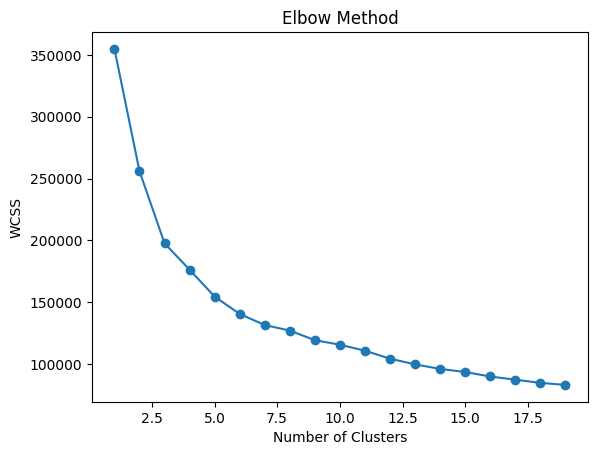

In [15]:
wcss = []

for i in range(1, 20):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 20), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [16]:
kmeans_8 = KMeans(n_clusters=8, random_state=42)
clusters_8 = kmeans_8.fit_predict(scaled_df)

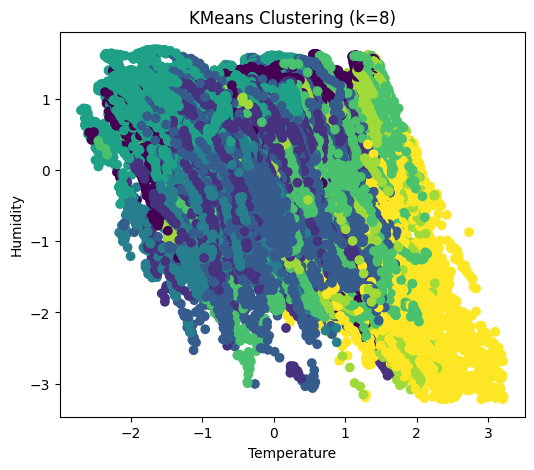

In [17]:
plt.figure(figsize=(6,5))
plt.scatter(scaled_df.iloc[:, 0], scaled_df.iloc[:, 1], c=clusters_8)
plt.title("KMeans Clustering (k=8)")
plt.xlabel(df.columns[0])
plt.ylabel(df.columns[1])
plt.show()